# Elliptic Bitcoin Transactions: Random-Split Contrast

Notebook 6 of 7. Many published Elliptic results use a random split of labelled nodes. This notebook reruns the whole pipeline (GraphSAGE, stacking, Random Forest, both LightGBM models) at the settings tuned on the temporal folds, but on a stratified random split whose test set has the same size as the temporal one. The gap between the two protocols measures how much a random split flatters every model. These numbers are optimistic by construction and are never the headline.

## Setup

The same GraphSAGE, sampling, loss, stacking and metric functions as notebooks 4 and 5. `SMOKE` keeps the full graph with one seed, five epochs and smaller forests; it is off in this version.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--progress-bar", "off", "torch_geometric==2.8.0.post1"], check=True, capture_output=True)

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch_geometric
from cycler import cycler
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import remove_self_loops, to_undirected

SMOKE = False
SEED = 42
THREADS = 4
RF_TREES = 100 if SMOKE else 500
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
PROTOCOL = {"temporal": "#52514e", "random": "#aeaca4"}
MODELS = ["rf", "raw_eng", "hybrid", "graphsage"]
MODEL_NAMES = {"rf": "Random Forest", "raw_eng": "LightGBM, raw + graph features", "hybrid": "GraphSAGE + LightGBM", "graphsage": "GraphSAGE"}
STRUCTURAL = ["in_degree", "out_degree", "pagerank", "core_number", "clustering", "avg_neighbor_degree", "two_hop_size"]
STACKING = ["gnn_logit", "gnn_in_mean", "gnn_in_max", "gnn_out_mean", "gnn_out_max"]
LOG1P = ("in_degree", "out_degree", "core_number", "avg_neighbor_degree", "two_hop_size")
LOG = ("pagerank",)
BASE = {"objective": "binary", "learning_rate": 0.05, "metric": "average_precision", "seed": SEED, "deterministic": True, "force_col_wise": True, "num_threads": THREADS, "verbose": -1, "bagging_freq": 1}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
torch.set_num_threads(THREADS)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_default_dtype(torch.float64)
START = time.time()


def gnn_matrix(raw, structural):
    values = np.array(structural, dtype=float)
    for name in LOG1P:
        i = STRUCTURAL.index(name)
        values[:, i] = np.log1p(values[:, i])
    for name in LOG:
        i = STRUCTURAL.index(name)
        values[:, i] = np.log(values[:, i])
    return np.hstack([np.asarray(raw, dtype=float), values])


class SAGE(torch.nn.Module):
    def __init__(self, d_in, hidden, layers, dropout):
        super().__init__()
        self.inp = torch.nn.Linear(d_in, hidden)
        self.convs = torch.nn.ModuleList([SAGEConv(hidden, hidden, aggr="mean") for _ in range(layers)])
        self.head = torch.nn.Linear(hidden * (layers + 1), 1)
        self.dropout = dropout

    def forward(self, x, edge_indices):
        h = F.dropout(F.relu(self.inp(x)), self.dropout, self.training)
        hidden = [h]
        for conv, edge_index in zip(self.convs, edge_indices):
            h = F.dropout(F.relu(conv(h, edge_index)), self.dropout, self.training)
            hidden.append(h)
        return self.head(torch.cat(hidden, dim=1)).squeeze(-1)


def sample_edges(edge_index, num_nodes, k, gen):
    dst = edge_index[1]
    key = dst.to(torch.float64) + torch.rand(dst.numel(), generator=gen, dtype=torch.float64)
    order = torch.argsort(key, stable=True)
    sorted_dst = dst[order]
    counts = torch.bincount(dst, minlength=num_nodes)
    starts = torch.cumsum(counts, 0) - counts
    rank = torch.arange(dst.numel()) - starts[sorted_dst]
    return edge_index[:, order[rank < k]]


def epoch_seeds(positives, negatives, ratio, gen):
    if ratio is None:
        return torch.cat([positives, negatives])
    take = min(len(negatives), int(ratio) * len(positives))
    pick = negatives[torch.randperm(len(negatives), generator=gen)[:take]]
    return torch.cat([positives, pick])


def focal_loss(logits, target, alpha, gamma):
    ce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    modulating = torch.exp(gamma * F.logsigmoid(logits * (1 - 2 * target)))
    a_t = alpha * target + (1 - alpha) * (1 - target)
    return (a_t * modulating * ce).mean()


def predict(model, x, edge):
    model.eval()
    with torch.no_grad():
        return model(x, [edge] * len(model.convs)).numpy().astype(np.float64)


def fit(params, fold, seed, epochs, checkpoints=(), balance=True, loss="focal"):
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    model = SAGE(X.shape[1], params["hidden"], params["layers"], params["dropout"])
    opt = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    in_fit = (FOLD != fold) & LABELLED
    positives = torch.tensor(np.flatnonzero(in_fit & (TRUE == 1)))
    negatives = torch.tensor(np.flatnonzero(in_fit & (TRUE == 0)))
    held = np.flatnonzero(FOLD == fold)
    history = {}
    for epoch in range(1, epochs + 1):
        model.train()
        seeds = epoch_seeds(positives, negatives, params["ratio"] if balance else None, gen)
        layer_edges = [sample_edges(EDGE, N, params["fanout"], gen) for _ in range(params["layers"])]
        out = model(X, layer_edges)[seeds]
        if loss == "focal":
            value = focal_loss(out, Y[seeds], params["alpha"], params["gamma"])
        else:
            value = F.binary_cross_entropy_with_logits(out, Y[seeds])
        opt.zero_grad()
        value.backward()
        opt.step()
        if epoch in checkpoints:
            history[epoch] = predict(model, X, EDGE)[held]
    return model, history


def directed(n, src, dst):
    src = np.asarray(src, dtype=np.int64)
    dst = np.asarray(dst, dtype=np.int64)
    keep = src != dst
    matrix = sparse.csr_matrix((np.ones(int(keep.sum())), (src[keep], dst[keep])), shape=(n, n))
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix


def segment_mean(matrix, values):
    counts = np.diff(matrix.indptr).astype(float)
    sums = np.asarray(matrix @ values, dtype=float)
    out = np.full(sums.shape, np.nan)
    has = counts > 0
    out[has] = sums[has] / counts[has, None]
    return out


def segment_max(matrix, values):
    out = np.full((matrix.shape[0], values.shape[1]), np.nan)
    has = np.diff(matrix.indptr) > 0
    if has.any():
        out[has] = np.maximum.reduceat(values[matrix.indices], matrix.indptr[:-1][has], axis=0)
    return out


def stacking_features(n, src, dst, logits):
    forward = directed(n, src, dst)
    backward = forward.T.tocsr()
    values = np.asarray(logits, dtype=float).reshape(n, 1)
    return np.hstack([
        values,
        segment_mean(backward, values),
        segment_max(backward, values),
        segment_mean(forward, values),
        segment_max(forward, values),
    ])


def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.asarray(values, dtype=float)))


def confusion(y, p, t):
    pred = p >= t
    tp = int((pred & (y == 1)).sum())
    fp = int((pred & (y == 0)).sum())
    fn = int((~pred & (y == 1)).sum())
    tn = int((~pred & (y == 0)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn, "precision": precision, "recall": recall, "f1": f1}


def metrics_at(y, p, t):
    return {"auc": float(roc_auc_score(y, p)), "pr_auc": float(average_precision_score(y, p)), **confusion(y, p, t), "threshold": float(t)}


def best_threshold(y, p):
    precision, recall, thresholds = precision_recall_curve(y, p)
    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    i = int(np.nanargmax(f1))
    return float(thresholds[i]), float(f1[i])


def matched_threshold(y, p, target):
    precision, recall, thresholds = precision_recall_curve(y, p)
    valid = np.flatnonzero(precision[:-1] >= target)
    return float(thresholds[valid[0]]) if len(valid) else 1.0


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


best = json.loads(find_file("best_params.json").read_text(encoding="utf-8"))
tabular = json.loads(find_file("best_params_tabular.json").read_text(encoding="utf-8"))
temporal = json.loads(find_file("metrics.json").read_text(encoding="utf-8"))
EPOCHS = 5 if SMOKE else int(best["epochs"])
SEEDS = [42] if SMOKE else [42, 43, 44]
print(f"smoke={SMOKE}, epochs={EPOCHS}, seeds={SEEDS}, rf trees {RF_TREES}")
print(f"torch {torch.__version__}, torch_geometric {torch_geometric.__version__}, lightgbm {lgb.__version__}")

smoke=False, epochs=75, seeds=[42, 43, 44], rf trees 500
torch 2.11.0+cpu, torch_geometric 2.8.0.post1, lightgbm 4.6.0


**Conclusion.** The full run reuses the temporally tuned settings without retuning: GraphSAGE for 75 epochs with three seeds per fold in float64, and the Random Forest (500 trees) and both LightGBM models at their tuned round counts.

## Build the full graph for the random split

Aim: assemble GraphSAGE inputs for all 203,769 nodes, since a random split mixes every time step into both training and test. Random-test labels are hidden (those nodes are never seeds), but the nodes stay in the graph next to training nodes from the same time step, which is exactly the leak this notebook measures.

In [2]:
feat = pd.read_parquet(find_file("features.parquet"))
split = pd.read_parquet(find_file("split.parquet"))
edges = pd.read_parquet(find_file("edges.parquet"))
meta = json.loads(find_file("feature_meta.json").read_text(encoding="utf-8"))
RAW, ENG = meta["raw"], meta["engineered"]
data = feat.merge(split[["txId", "random_set", "random_fold"]], on="txId").reset_index(drop=True)
x_np = gnn_matrix(data[RAW].to_numpy(np.float64), data[STRUCTURAL].to_numpy(np.float64))
MEAN = x_np.mean(axis=0)
STD = x_np.std(axis=0)
STD[STD == 0] = 1.0
X = torch.tensor((x_np - MEAN) / STD, dtype=torch.float64)
LABEL = data.label.to_numpy()
LABELLED = (data.random_set == "train").to_numpy()
TRUE = (LABEL == 1).astype(int)
Y = torch.tensor(TRUE, dtype=torch.float64)
FOLD = data.random_fold.to_numpy()
N = len(data)
pos = pd.Series(np.arange(N), index=data.txId.to_numpy())
src = pos.loc[edges.txId1].to_numpy()
dst = pos.loc[edges.txId2].to_numpy()
pairs, _ = remove_self_loops(torch.tensor(np.vstack([src, dst]), dtype=torch.long))
EDGE = to_undirected(pairs, num_nodes=N)
print(f"nodes {N:,}, random train {int(LABELLED.sum()):,}, random test {int((data.random_set == 'test').sum()):,}, symmetrised edges {EDGE.shape[1]:,}")

nodes 203,769, random train 29,894, random test 16,670, symmetrised edges 468,710


**Conclusion.** The random split covers the whole graph: 203,769 transactions and 468,710 symmetrised edges, with 29,894 random-train and 16,670 random-test labelled transactions, the same test size as the temporal split. Random-test transactions keep their place in the graph with their labels hidden, so they share every time step, and often direct links, with random-train transactions.

## GraphSAGE on the random split

Aim: train 15 fold models at the tuned settings on the five stratified random folds; a random-train node's logit comes from its fold's three models, every other node's from all 15. Then build the five stacking features exactly as in notebook 4.

In [3]:
logit = np.zeros(N)
outside = FOLD < 0
for fold in range(5):
    held = np.flatnonzero(FOLD == fold)
    fold_pred = np.zeros(len(held))
    for seed in SEEDS:
        model, _ = fit(best, fold, seed, EPOCHS)
        out = predict(model, X, EDGE)
        fold_pred += out[held] / len(SEEDS)
        logit[outside] += out[outside] / (5 * len(SEEDS))
    logit[held] = fold_pred
    print(f"fold {fold} done, {elapsed()}")
stack = stacking_features(N, src, dst, logit.astype(np.float32)).astype(np.float32)
for i, name in enumerate(STACKING):
    data[name] = stack[:, i]

fold 0 done, elapsed 10.9 minutes
fold 1 done, elapsed 21.7 minutes
fold 2 done, elapsed 32.8 minutes
fold 3 done, elapsed 43.5 minutes
fold 4 done, elapsed 54.2 minutes


**Conclusion.** Fifteen GraphSAGE models trained in about an hour on the full graph, each random-train transaction scored by its own fold's three models and every other transaction by all 15, and the five stacking features were rebuilt exactly as in notebook 4.

## Tabular models and the random-test evaluation

Aim: refit Random Forest, LightGBM A and the hybrid at their temporally tuned settings (fixed rounds, no retuning), set F1-optimal and matched-precision thresholds on random out-of-fold predictions, and score the random test set once.

In [4]:
SETS = {"rf": RAW, "raw_eng": RAW + ENG, "hybrid": RAW + ENG + STACKING}
rtrain = data[data.random_set == "train"].reset_index(drop=True)
rtest = data[data.random_set == "test"].reset_index(drop=True)
y = rtrain.label.to_numpy().astype(int)
folds = rtrain.random_fold.to_numpy()
y_test = rtest.label.to_numpy().astype(int)
OOF = {name: np.zeros(len(rtrain)) for name in ("rf", "raw_eng", "hybrid")}
for k in range(5):
    fit_rows = folds != k
    rf = RandomForestClassifier(n_estimators=RF_TREES, n_jobs=THREADS, random_state=SEED, **tabular["rf"]).fit(rtrain.loc[fit_rows, RAW].to_numpy(np.float32), y[fit_rows])
    OOF["rf"][~fit_rows] = rf.predict_proba(rtrain.loc[~fit_rows, RAW].to_numpy(np.float32))[:, 1]
    for name in ("raw_eng", "hybrid"):
        booster = lgb.train({**BASE, **tabular[name]["params"]}, lgb.Dataset(rtrain.loc[fit_rows, SETS[name]], y[fit_rows]), num_boost_round=tabular[name]["rounds"])
        OOF[name][~fit_rows] = booster.predict(rtrain.loc[~fit_rows, SETS[name]])
OOF["graphsage"] = sigmoid(rtrain.gnn_logit.to_numpy())
THRESH = {name: best_threshold(y, p)[0] for name, p in OOF.items()}
OOF_METRICS = {name: metrics_at(y, OOF[name], THRESH[name]) for name in MODELS}
RF_PRECISION = OOF_METRICS["rf"]["precision"]
MATCHED = {name: matched_threshold(y, OOF[name], RF_PRECISION) for name in ("raw_eng", "hybrid", "graphsage")}
rf = RandomForestClassifier(n_estimators=RF_TREES, n_jobs=THREADS, random_state=SEED, **tabular["rf"]).fit(rtrain[RAW].to_numpy(np.float32), y)
TEST = {"rf": rf.predict_proba(rtest[RAW].to_numpy(np.float32))[:, 1]}
for name in ("raw_eng", "hybrid"):
    booster = lgb.train({**BASE, **tabular[name]["params"]}, lgb.Dataset(rtrain[SETS[name]], y), num_boost_round=tabular[name]["rounds"])
    TEST[name] = booster.predict(rtest[SETS[name]])
TEST["graphsage"] = sigmoid(rtest.gnn_logit.to_numpy())
results = {name: metrics_at(y_test, TEST[name], THRESH[name]) for name in MODELS}
matched = {name: metrics_at(y_test, TEST[name], MATCHED[name]) for name in MATCHED}
fn_rf = results["rf"]["fn"]
reduction = {"own": {n: (fn_rf - results[n]["fn"]) / fn_rf for n in MODELS if n != "rf"}, "matched": {n: (fn_rf - matched[n]["fn"]) / fn_rf for n in MATCHED}}
for name in MODELS:
    m = results[name]
    print(f"{name}: random-test auc {m['auc']:.4f}, pr_auc {m['pr_auc']:.4f}, f1 {m['f1']:.4f}, precision {m['precision']:.4f}, recall {m['recall']:.4f}, fn {m['fn']}")
print(f"false-negative reduction vs random forest: {({k: {n: round(v, 4) for n, v in d.items()} for k, d in reduction.items()})}")
print(elapsed())

rf: random-test auc 0.9965, pr_auc 0.9813, f1 0.9399, precision 0.9681, recall 0.9133, fn 141
raw_eng: random-test auc 0.9980, pr_auc 0.9893, f1 0.9614, precision 0.9747, recall 0.9484, fn 84
hybrid: random-test auc 0.9983, pr_auc 0.9901, f1 0.9586, precision 0.9722, recall 0.9453, fn 89
graphsage: random-test auc 0.9905, pr_auc 0.9591, f1 0.9134, precision 0.9472, recall 0.8820, fn 192
false-negative reduction vs random forest: {'own': {'raw_eng': 0.4043, 'hybrid': 0.3688, 'graphsage': -0.3617}, 'matched': {'raw_eng': 0.4752, 'hybrid': 0.4113, 'graphsage': -0.7021}}
elapsed 58.9 minutes


**Conclusion.** On the random test set every model looks excellent: the hybrid reaches an AUC-ROC of 0.998 and an illicit F1 of 0.959, LightGBM A 0.998 and 0.961, the Random Forest 0.997 and 0.940, and GraphSAGE alone 0.991 and 0.913. Under this protocol the tree models also miss far fewer illicit transactions than the Random Forest (the hybrid 37% fewer at its own threshold and 41% fewer at matched precision). In other words, the random split clears every resume benchmark easily, which is a strong hint about how such numbers are usually produced on Elliptic.

## Temporal against random

Aim: put the two protocols side by side for every model. The difference is how much a random split inflates each metric on this dataset.

    model metric  temporal  random    gap
       rf    auc    0.9279  0.9965 0.0686
       rf pr_auc    0.7907  0.9813 0.1906
       rf     f1    0.6899  0.9399 0.2500
       rf recall    0.7405  0.9133 0.1728
  raw_eng    auc    0.9461  0.9980 0.0519
  raw_eng pr_auc    0.8120  0.9893 0.1773
  raw_eng     f1    0.8028  0.9614 0.1585
  raw_eng recall    0.7350  0.9484 0.2134
   hybrid    auc    0.9501  0.9983 0.0482
   hybrid pr_auc    0.8180  0.9901 0.1721
   hybrid     f1    0.8186  0.9586 0.1400
   hybrid recall    0.7165  0.9453 0.2288
graphsage    auc    0.8922  0.9905 0.0983
graphsage pr_auc    0.6484  0.9591 0.3106
graphsage     f1    0.6136  0.9134 0.2999
graphsage recall    0.5051  0.8820 0.3769


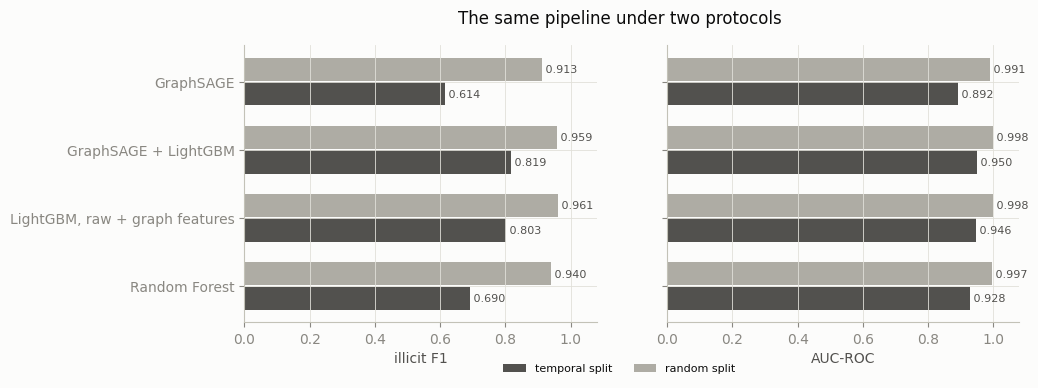

In [5]:
contrast = []
for name in MODELS:
    for metric in ("auc", "pr_auc", "f1", "recall"):
        contrast.append({"model": name, "metric": metric, "temporal": float(temporal["test"][name][metric]), "random": float(results[name][metric])})
table = pd.DataFrame(contrast)
table["gap"] = table["random"] - table["temporal"]
print(table.round(4).to_string(index=False))
metrics_random = {"oof": OOF_METRICS, "test": results, "matched": matched, "thresholds": THRESH, "matched_thresholds": MATCHED, "fn_reduction": reduction, "contrast": contrast}
(OUT / "metrics_random.json").write_text(json.dumps(metrics_random, indent=2, allow_nan=False), encoding="utf-8")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, metric in zip(axes, ("f1", "auc")):
    part = table[table.metric == metric]
    ypos = np.arange(len(MODELS))
    ax.barh(ypos - 0.18, part.temporal, height=0.34, color=PROTOCOL["temporal"], label="temporal split")
    ax.barh(ypos + 0.18, part.random, height=0.34, color=PROTOCOL["random"], label="random split")
    for yy, (t, r) in enumerate(zip(part.temporal, part.random)):
        ax.text(t, yy - 0.18, f" {t:.3f}", va="center", color=INK_2, fontsize=8)
        ax.text(r, yy + 0.18, f" {r:.3f}", va="center", color=INK_2, fontsize=8)
    ax.set_yticks(ypos, [MODEL_NAMES[m] for m in MODELS])
    ax.set(xlabel="illicit F1" if metric == "f1" else "AUC-ROC", xlim=(0, 1.08))
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("The same pipeline under two protocols", color=INK)
save(fig, "temporal_vs_random")

**Conclusion.** The same pipeline loses a great deal under the honest temporal protocol: illicit F1 drops by 0.14 for the hybrid, 0.16 for LightGBM A, 0.25 for the Random Forest and 0.30 for GraphSAGE alone, and AUC-ROC by 0.05 to 0.10. GraphSAGE suffers most and the Random Forest next, whose threshold transfers badly across the drift. A random split puts training transactions from the same time step next to each test transaction and shares their market regime; this contrast alone does not separate how much of GraphSAGE's gain comes from each. These random-split numbers are optimistic by construction; every headline result in this project comes from the temporal split in notebook 5.